# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

|          Nama          |    NRP     |
|------------------------|------------|
| Muhammad Fardan Hafidz | 5054251021 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [20]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, accuracy_score, classification_report, confusion_matrix, f1_score, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, CategoricalNB


In [21]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.

df = pd.read_csv('/kaggle/input/datasets/uciml/mushroom-classification/mushrooms.csv') # URL kalo pake kaggle
df.head()

# df.info()
# df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [22]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.

print(f"Bentuk dataset: {df.shape[0]} baris, {df.shape[1]} kolom\n")
print("Tipe data setiap kolom:")
print(df.dtypes)

print("\nJumlah missing value (secara eksplisit null/NaN):")
print(df.isnull().sum())

print("\nJumlah nilai '?' pada kolom stalk-root:")
print((df['stalk-root'] == '?').sum())

Bentuk dataset: 8124 baris, 23 kolom

Tipe data setiap kolom:
class                       object
cap-shape                   object
cap-surface                 object
cap-color                   object
bruises                     object
odor                        object
gill-attachment             object
gill-spacing                object
gill-size                   object
gill-color                  object
stalk-shape                 object
stalk-root                  object
stalk-surface-above-ring    object
stalk-surface-below-ring    object
stalk-color-above-ring      object
stalk-color-below-ring      object
veil-type                   object
veil-color                  object
ring-number                 object
ring-type                   object
spore-print-color           object
population                  object
habitat                     object
dtype: object

Jumlah missing value (secara eksplisit null/NaN):
class                       0
cap-shape                   0
cap-surf

In [23]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.

unique_counts = df.nunique()
print("Jumlah nilai unik per kolom:")
print(unique_counts)

Jumlah nilai unik per kolom:
class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64


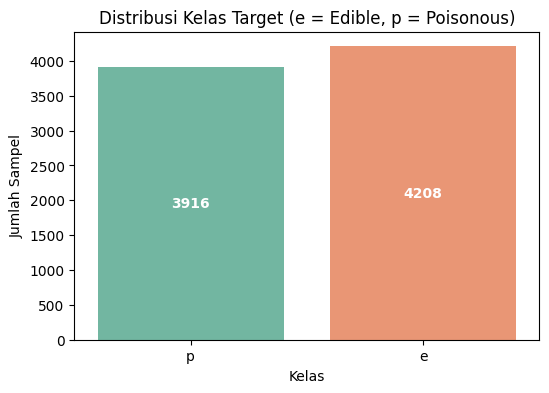

Persentase target:
class
e    51.797144
p    48.202856
Name: proportion, dtype: float64


In [24]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='class', hue='class', palette='Set2', legend=False)
plt.title('Distribusi Kelas Target (e = Edible, p = Poisonous)')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Sampel')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height() / 2), 
                ha='center', va='center', color='white', fontweight='bold')

plt.show()

print("Persentase target:")
print(df['class'].value_counts(normalize=True) * 100)

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [25]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.

# Menjadikan '?' sebagai kategori tersendiri ('missing' / 'unknown') 
# agar tidak membuang 30% baris data berharga.
df['stalk-root'] = df['stalk-root'].replace('?', 'missing')
print("Distribusi nilai unik stalk-root setelah diubah:")
print(df['stalk-root'].value_counts())

Distribusi nilai unik stalk-root setelah diubah:
stalk-root
b          3776
missing    2480
e          1120
c           556
r           192
Name: count, dtype: int64


In [26]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.

cols_to_drop = [col for col in df.columns if df[col].nunique() <= 1]
print(f"Menghapus kolom: {cols_to_drop}")
df = df.drop(columns=cols_to_drop)

Menghapus kolom: ['veil-type']


In [27]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = df.drop(columns=['class'])
y = df['class'].map({'e': 0, 'p': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dimensi X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Distribusi label train: \n{y_train.value_counts(normalize=True)}")

Dimensi X_train: (6499, 21), X_test: (1625, 21)
Distribusi label train: 
class
0    0.517926
1    0.482074
Name: proportion, dtype: float64


In [28]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_oe = oe.fit_transform(X_train)
X_test_oe = oe.transform(X_test)

In [29]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_ohe = ohe.fit_transform(X_train)
X_test_ohe = ohe.transform(X_test)

print(f"Dimensi fitur setelah OneHotEncoding: {X_train_ohe.shape[1]} kolom biner")

Dimensi fitur setelah OneHotEncoding: 116 kolom biner


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [30]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.
cnb = CategoricalNB()
cnb.fit(X_train_oe, y_train)

CategoricalNB()

In [31]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_cnb = cnb.predict(X_test_oe)
y_proba_cnb = cnb.predict_proba(X_test_oe)[:, 1]

## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [32]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.

bnb = BernoulliNB()
bnb.fit(X_train_ohe, y_train)

BernoulliNB()

In [33]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_bnb = bnb.predict(X_test_ohe)
y_proba_bnb = bnb.predict_proba(X_test_ohe)[:, 1]

## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [34]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.

mnb = MultinomialNB()
mnb.fit(X_train_ohe, y_train)

MultinomialNB()

In [35]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_mnb = mnb.predict(X_test_ohe)
y_proba_mnb = mnb.predict_proba(X_test_ohe)[:, 1]

# 4. Evaluasi Model

In [36]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

models = {
    'Categorical NB': (y_pred_cnb, y_proba_cnb),
    'Bernoulli NB': (y_pred_bnb, y_proba_bnb),
    'Multinomial NB': (y_pred_mnb, y_proba_mnb)
}

metrics_list = []
for name, (pred, proba) in models.items():
    metrics_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba)
    })

metrics_df = pd.DataFrame(metrics_list)
display(metrics_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Categorical NB,0.945846,0.990127,0.896552,0.941019,0.997185
1,Bernoulli NB,0.932923,0.981429,0.877395,0.926500,0.995428
2,Multinomial NB,0.945846,0.990127,0.896552,0.941019,0.997185


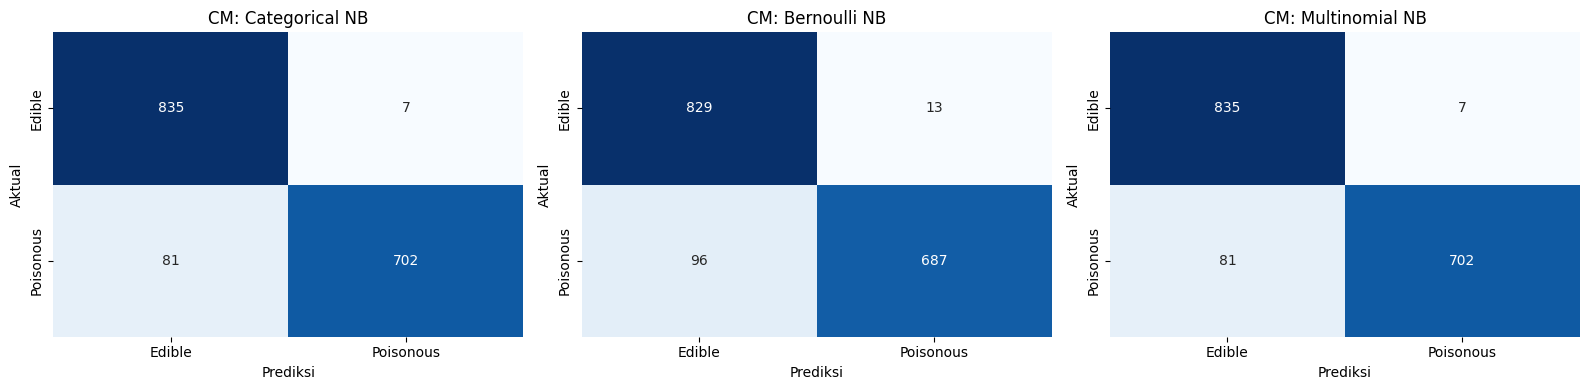

In [37]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, (pred, _)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Edible', 'Poisonous'], 
                yticklabels=['Edible', 'Poisonous'])
    ax.set_title(f'CM: {name}')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.show()

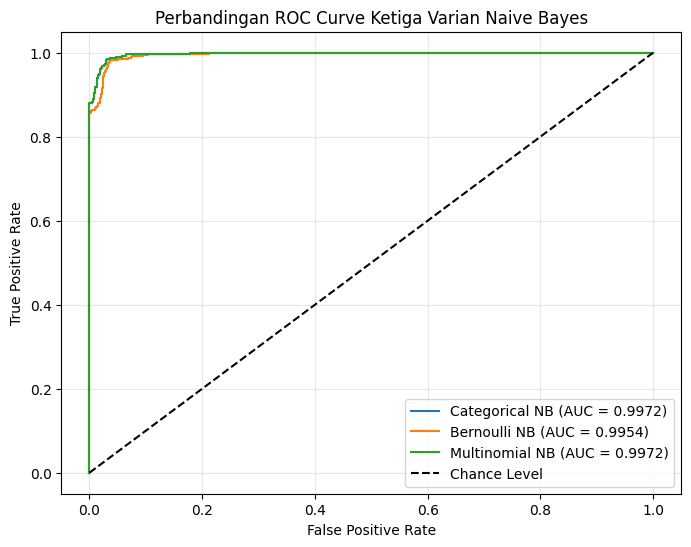

In [38]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.

plt.figure(figsize=(8, 6))

for name, (_, proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance Level')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Perbandingan ROC Curve Ketiga Varian Naive Bayes')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# 5. Analisis

#### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Categorical NB, Bernoulli NB, dan Multinomial NB berdasarkan hasil evaluasi. Kaitkan perbedaan performa dengan perbedaan representasi data yang digunakan oleh masing-masing model. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

Berdasarkan hasil eksperimen diatas terhadap data test (test set) sebanyak 1625 data, didapatkan evaluasi metrik sebagai berikut:

1. Model Kategorikal:
    * Akurasi: 94.58%
    * Precision: 99.01%
    * Recall: 89.66%
    * F1-Score: 94.10%
    * ROC-AUC: 0.9972
    * Confusion Matrix: 835 sampel edible berhasil ditebak benar (True Negative), 702 sampel poisonous ditebak benar (True Positive), hanya 7 sampel edible yang salah dikira beracun (False Positive), dan 81 sampel jamur beracun salah tertebak sebagai aman (False Negative).

2. Model Bernoulli:
    * Akurasi: 93.29%
    * Precision: 98.14%
    * Recall: 87.74%
    * F1-Score: 92.65%
    * ROC-AUC: 0.9954
    * Confusion Matrix: 829 sampel edible berhasil ditebak benar (True Negative), 687 sampel poisonous ditebak benar (True Positive), 13 sampel edible salah dikira beracun (False Positive), dan terdapat 96 sampel jamur beracun yang salah dikira aman (False Negative).

3. Model Multinomial:
    * Akurasi: 94.58%
    * Precision: 99.01%
    * Recall: 89.66%
    * F1-Score: 94.10%
    * ROC-AUC: 0.9972
    * Confusion Matrix: Memberikan hasil klasifikasi yang sama persis dengan Categorical NB, yaitu 835 sampel edible berhasil ditebak benar (True Negative), 702 sampel poisonous ditebak benar (True Positive), 7 sampel edible salah dikira beracun (False Positive), dan 81 sampel jamur beracun salah tertebak sebagai aman (False Negative).

Perbandingan dan Analisis Representasi Data:
* **Categorical NB**: Bekerja paling alami dengan OrdinalEncoder karena fiturnya memang kategorikal nominal. Model menghitung probabilitas tiap kategori secara langsung tanpa memecah kolom (tetap 21 fitur), menghasilkan akurasi tinggi 94.58% dan ROC-AUC 0.9972.
* **Multinomial NB**: Menghasilkan performa yang persis sama dengan Categorical NB. Matriks one-hot (116 kolom) diperlakukan seperti frekuensi kemunculan fitur berpanjang konstan (tiap baris selalu punya 21 nilai aktif). Model hanya fokus pada fitur yang muncul (nilai 1) tanpa terbebani penalti nilai 0.
* **Bernoulli NB**: Performa paling rendah (Akurasi 93.29%, Recall 87.74%). Model ini memperhitungkan kehadiran (1) sekaligus ketiadaan (0) fitur. Sifat mutually exclusive pada data one-hot membuat ketiadaan kategori dihitung berulang-ulang, mendistorsi asumsi independensi Naive Bayes, dan menambah kesalahan False Negative hingga 96 sampel.
* **Aspek Keselamatan**: Metrik terpenting dalam hal keselamatan adalah **Recall kelas beracun** untuk meminimalkan False Negative (jamur beracun dikira aman). Categorical NB dan Multinomial NB terbukti lebih aman karena hanya meloloskan 81 jamur beracun, dibanding Bernoulli NB yang meloloskan 96 sampel.

# 6. Kesimpulan dan Saran

#### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Ketiga model varian Naive Bayes dapat mengklasifikasikan dataset jamur dengan performa tinggi di atas 93% dan ROC-AUC melampaui 0.995. Categorical NB dan Multinomial NB menjadi model terbaik dengan performa seimbang dan identik (Akurasi 94.58%, F1-Score 94.10%), sekaligus lebih unggul dalam meminimalkan False Negative dibanding Bernoulli NB.

Saran yang bisa dipertimbangkan:
* **Seleksi Fitur (Feature Selection):** Kita dapat melakukan seleksi fitur dominan (seperti odor atau spore-print-color) untuk memangkas dimensi 116 kolom one-hot tanpa banyak menurunkan akurasi.
* **Tuning Hyperparameter:** Eksplorasi nilai parameter perataan Laplace (alpha) pada masing-masing model untuk mengoptimalkan penanganan kategori yang frekuensinya langka.